## Step 0-Setup & installs


In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

CKPT_DIR = '/kaggle/working/checkpoints'
CKPT_SRC = '/kaggle/input/notebooks/starkcover/notebook14fbec758d/checkpoints'
OUT_DIR  = '/kaggle/working/figures'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)


In [ ]:
!pip install rdkit shap umap-learn matplotlib seaborn scikit-learn -q
!pip install chembl_webresource_client -q
import torch
TORCH = torch.__version__.split('+')[0]
CUDA  = 'cu' + torch.version.cuda.replace('.','') if torch.cuda.is_available() else 'cpu'
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html -q
!pip install torch_geometric -q
print("Installs done")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 762.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.8/827.8 kB 51.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 900.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.4 MB/s eta 0:00:00
Installs done


## Step 1-Load base checkpoints


In [ ]:
import shutil, torch, numpy as np, pandas as pd

needed = [
    'df_with_chembl.parquet', 'dti_df.parquet',
    'drug_features_tensor.pt',
    'protein_df.parquet', 'protein_sequences.parquet',
]
if os.path.exists(CKPT_SRC):
    for f in needed:
        d = f'{CKPT_DIR}/{f}'
        s = f'{CKPT_SRC}/{f}'
        if not os.path.exists(d) and os.path.exists(s):
            shutil.copy(s, d); print(f'Copied: {f}')
        elif os.path.exists(d):
            print(f'Present: {f}')
        else:
            print(f'NOT FOUND: {f}')
else:
    print('Source dir not found — assuming files in CKPT_DIR')

df                   = pd.read_parquet(f'{CKPT_DIR}/df_with_chembl.parquet').reset_index(drop=True)
dti_df               = pd.read_parquet(f'{CKPT_DIR}/dti_df.parquet')
drug_features_tensor = torch.load(f'{CKPT_DIR}/drug_features_tensor.pt', weights_only=False)
protein_seq_df       = pd.read_parquet(f'{CKPT_DIR}/protein_sequences.parquet')

# Parse labels
label_col = 'Drug-induced ototoxicity'
str_map   = {'positive':1,'Positive':1,'1':1,1:1,
             'negative':0,'Negative':0,'0':0,0:0}
labels_all = df[label_col].map(str_map).fillna(0).astype(int).values
assert labels_all.sum() > 0, "All labels zero — check label column"

print(f"df: {df.shape} | Non-toxic: {(labels_all==0).sum()} | Ototoxic: {(labels_all==1).sum()}")
print(f"dti_df: {dti_df.shape}")
print(f"drug_features_tensor: {drug_features_tensor.shape}")
print("Checkpoints loaded")


## Step 2-Column Splitting



In [ ]:
from sklearn.model_selection import train_test_split

split_col  = 'Data set'
split_raw  = df[split_col].str.strip().str.lower()
train_idx  = np.where(split_raw == 'training')[0]
val_idx    = np.where(split_raw == 'external validation')[0]
test_idx   = np.where(split_raw == 'test')[0]

if len(val_idx) == 0:
    train_idx, val_idx = train_test_split(
        train_idx, test_size=0.15,
        stratify=labels_all[train_idx], random_state=42)
    print("No external validation set — carved 15% from train")

train_set = set(train_idx.tolist())

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
print(f"Positive rate — train: {labels_all[train_idx].mean():.3f} | "
      f"val: {labels_all[val_idx].mean():.3f} | "
      f"test: {labels_all[test_idx].mean():.3f}")


Train: 2121 | Val: 450 | Test: 237
Positive rate — train: 0.419 | val: 0.256 | test: 0.422


 Step 3-protein features (physicochemical descriptors)

ESM-2 requires GPU. We use RDKit-style physicochemical descriptors over the
amino acid sequence instead; 200 dim, much richer than 20 dim AA composition.
Swap the `compute_protein_features` function for ESM-2 if GPU is available.


In [ ]:
import numpy as np

CKPT_PROT_FEAT2 = f'{CKPT_DIR}/protein_features_v2.npy'
CKPT_PROT_MAP2  = f'{CKPT_DIR}/protein_map_v2.parquet'

AA = list('ACDEFGHIKLMNPQRSTVWY')

# Physicochemical property tables
HYDRO  = {'A':1.8,'C':2.5,'D':-3.5,'E':-3.5,'F':2.8,'G':-0.4,'H':-3.2,
          'I':4.5,'K':-3.9,'L':3.8,'M':1.9,'N':-3.5,'P':-1.6,'Q':-3.5,
          'R':-4.5,'S':-0.8,'T':-0.7,'V':4.2,'W':-0.9,'Y':-1.3}
CHARGE = {'D':-1,'E':-1,'K':1,'R':1,'H':0.1}
POLAR  = {'S','T','N','Q','Y','C'}
AROM   = {'F','W','Y','H'}
MW_AA  = {'A':89,'C':121,'D':133,'E':147,'F':165,'G':75,'H':155,'I':131,
          'K':146,'L':131,'M':149,'N':132,'P':115,'Q':146,'R':174,'S':105,
          'T':119,'V':117,'W':204,'Y':181}

def compute_protein_features(seq):
    seq   = seq.upper()
    n     = max(len(seq), 1)
    feats = []
    # 20 AA frequencies
    feats += [seq.count(aa)/n for aa in AA]
    # Hydrophobicity mean + std
    hvals = [HYDRO.get(aa, 0) for aa in seq]
    feats += [np.mean(hvals), np.std(hvals)]
    # Net charge
    charge = sum(CHARGE.get(aa, 0) for aa in seq) / n
    feats += [charge]
    # Polar fraction
    feats += [sum(1 for aa in seq if aa in POLAR) / n]
    # Aromatic fraction
    feats += [sum(1 for aa in seq if aa in AROM) / n]
    # Mean molecular weight
    feats += [np.mean([MW_AA.get(aa, 110) for aa in seq])]
    # Dipeptide frequencies (top 100 most common dipeptides)
    dipeps = [seq[i:i+2] for i in range(len(seq)-1)]
    top_dips = [''.join([a,b]) for a in 'ACDEFGHIKLMNPQRSTVWY'[:10]
                               for b in 'ACDEFGHIKLMNPQRSTVWY'[:10]]
    dp_counts = {d: 0 for d in top_dips}
    for dp in dipeps:
        if dp in dp_counts:
            dp_counts[dp] += 1
    total_dp = max(len(dipeps), 1)
    feats += [v/total_dp for v in dp_counts.values()]
    return np.array(feats, dtype=np.float32)  # 20+2+1+1+1+1+100 = 126 dim

if os.path.exists(CKPT_PROT_FEAT2):
    print("Loading v2 protein features from checkpoint …")
    protein_features = np.load(CKPT_PROT_FEAT2)
    protein_map_df   = pd.read_parquet(CKPT_PROT_MAP2)
else:
    print("Computing v2 protein features …")
    feats = np.array([compute_protein_features(s)
                      for s in protein_seq_df['sequence']])
    protein_features = feats
    np.save(CKPT_PROT_FEAT2, protein_features)
    protein_seq_df[['target_id','uniprot_id']].reset_index(drop=True).to_parquet(CKPT_PROT_MAP2, index=False)
    print(f"Saved → {CKPT_PROT_FEAT2}")

protein_map_df = pd.read_parquet(CKPT_PROT_MAP2)
protein_map    = {row.target_id: i for i, row in enumerate(protein_map_df.itertuples())}

print(f"Protein feature matrix: {protein_features.shape}")
print(f"Protein map entries:    {len(protein_map)}")


Computing v2 protein features …
Saved → /kaggle/working/checkpoints/protein_features_v2.npy
Protein feature matrix: (764, 126)
Protein map entries:    151


## Step 4-richer DTI edges (activity table, not just mechanism)


In [ ]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

CKPT_DTI2 = f'{CKPT_DIR}/dti_df_v2.parquet'

if os.path.exists(CKPT_DTI2):
    print("Loading v2 DTI from checkpoint …")
    dti_df2 = pd.read_parquet(CKPT_DTI2)
else:
    print("Fetching activity-based DTI from ChEMBL (IC50/Ki <= 1000 nM) …")
    activity_api = new_client.activity
    has_chembl   = df['chembl_id'].notnull()
    mapped_ids   = df.loc[has_chembl, 'chembl_id'].unique().tolist()

    records = []
    BATCH = 50
    for start in range(0, len(mapped_ids), BATCH):
        batch = mapped_ids[start:start+BATCH]
        acts  = activity_api.filter(
            molecule_chembl_id__in=batch,
            standard_type__in=['IC50','Ki','Kd','EC50'],
            standard_units='nM',
            standard_value__lte=1000,
            assay_type='B'
        ).only(['molecule_chembl_id','target_chembl_id'])
        for a in acts:
            if a.get('target_chembl_id'):
                records.append({
                    'drug_id':   a['molecule_chembl_id'],
                    'target_id': a['target_chembl_id']
                })
        if (start // BATCH) % 5 == 0:
            print(f"  processed {min(start+BATCH, len(mapped_ids))}/{len(mapped_ids)} drugs …")

    # Also keep original mechanism edges
    mech_records = [{'drug_id': r['drug_id'], 'target_id': r['target_id']}
                    for _, r in dti_df.iterrows()]

    all_records = records + mech_records
    dti_df2 = pd.DataFrame(all_records).drop_duplicates()
    dti_df2.to_parquet(CKPT_DTI2, index=False)
    print(f"Saved → {CKPT_DTI2}")

print(f"v1 DTI edges: {len(dti_df)}")
print(f"v2 DTI edges: {len(dti_df2)}  ({len(dti_df2)-len(dti_df):+d} new edges)")
dti_df2.head()


Fetching activity-based DTI from ChEMBL (IC50/Ki <= 1000 nM) …
  processed 50/2128 drugs …
  processed 300/2128 drugs …
  processed 550/2128 drugs …
  processed 800/2128 drugs …
  processed 1050/2128 drugs …
  processed 1300/2128 drugs …
  processed 1550/2128 drugs …
  processed 1800/2128 drugs …
  processed 2050/2128 drugs …
Saved → /kaggle/working/checkpoints/dti_df_v2.parquet
v1 DTI edges: 645
v2 DTI edges: 5551  (+4906 new edges)


,drug_id,target_id
0,CHEMBL41,CHEMBL313
1,CHEMBL41,CHEMBL2093870
2,CHEMBL41,CHEMBL1907610
3,CHEMBL41,CHEMBL339
4,CHEMBL423,CHEMBL213


## Step 5-build leak free graph with k-NN edges + richer protein features


In [ ]:
from torch_geometric.data import HeteroData
from rdkit import DataStructs, Chem
from rdkit.Chem import rdFingerprintGenerator

CKPT_GRAPH_FINAL = f'{CKPT_DIR}/hetero_data_final.pt'

if os.path.exists(CKPT_GRAPH_FINAL):
    print("Loading final graph from checkpoint …")
    data = torch.load(CKPT_GRAPH_FINAL, weights_only=False)
else:
    print("Building final leak-free graph …")
    data = HeteroData()

    # Drug nodes
    data['drug'].x = drug_features_tensor
    data['drug'].y = torch.tensor(labels_all, dtype=torch.long)

    # Protein nodes — v2 richer features
    data['protein'].x = torch.tensor(protein_features, dtype=torch.float)

    # Drug→Protein edges using richer DTI (activity-based)
    drug_to_idx = {row['chembl_id']: pos
                   for pos, (_, row) in enumerate(df.iterrows())
                   if pd.notnull(row.get('chembl_id'))}

    edge_list = []
    for _, row in dti_df2.iterrows():
        if row['drug_id'] in drug_to_idx and row['target_id'] in protein_map:
            edge_list.append([drug_to_idx[row['drug_id']],
                               protein_map[row['target_id']]])
    if edge_list:
        ei = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        data['drug', 'interacts', 'protein'].edge_index = ei
        print(f"  Drug→Protein edges: {ei.shape[1]}")

    # FIX: k-NN similarity edges (train-only, k=15 per drug)
    # Every training drug gets edges regardless of threshold
    print("  Computing k-NN similarity edges (k=15, train-only) …")
    mfpgen   = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    K_NEIGH  = 15

    fps_rdkit = []
    for smi in df['canonical_smiles']:
        mol = Chem.MolFromSmiles(smi)
        fps_rdkit.append(mfpgen.GetFingerprint(mol) if mol else None)

    sim_edges = []
    train_list = sorted(train_idx.tolist())
    for ii, i in enumerate(train_list):
        if fps_rdkit[i] is None:
            continue
        rest     = [j for j in train_list[ii+1:] if fps_rdkit[j] is not None]
        if not rest:
            continue
        rest_fps = [fps_rdkit[j] for j in rest]
        sims     = np.array(DataStructs.BulkTanimotoSimilarity(fps_rdkit[i], rest_fps))
        topk     = np.argsort(sims)[::-1][:K_NEIGH]
        for k in topk:
            j = rest[k]
            sim_edges.append([i, j])
            sim_edges.append([j, i])

    if sim_edges:
        se = torch.tensor(sim_edges, dtype=torch.long).t().contiguous()
        data['drug', 'similar_to', 'drug'].edge_index = se
        print(f"  Drug→Drug k-NN edges (train-only, k={K_NEIGH}): {se.shape[1]}")

    torch.save(data, CKPT_GRAPH_FINAL)
    print(f"Saved → {CKPT_GRAPH_FINAL}")

print(data)


Building final leak-free graph …
  Drug→Protein edges: 1266
  Computing k-NN similarity edges (k=15, train-only) …
  Drug→Drug k-NN edges (train-only, k=15): 63390
Saved → /kaggle/working/checkpoints/hetero_data_final.pt
HeteroData(
  drug={
    x=[2808, 2048],
    y=[2808],
  },
  protein={ x=[764, 126] },
  (drug, interacts, protein)={ edge_index=[2, 1266] },
  (drug, similar_to, drug)={ edge_index=[2, 63390] }
)


## Step 6-attach masks


In [ ]:
n = data['drug'].num_nodes
data['drug'].train_mask = torch.zeros(n, dtype=torch.bool)
data['drug'].val_mask   = torch.zeros(n, dtype=torch.bool)
data['drug'].test_mask  = torch.zeros(n, dtype=torch.bool)
data['drug'].train_mask[train_idx] = True
data['drug'].val_mask[val_idx]     = True
data['drug'].test_mask[test_idx]   = True

print(f"Train: {data['drug'].train_mask.sum().item()} | "
      f"Val: {data['drug'].val_mask.sum().item()} | "
      f"Test: {data['drug'].test_mask.sum().item()}")


Train: 2121 | Val: 450 | Test: 237


## Step 7-deeper GNN with BatchNorm + residual connections


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn as nn

class GNNv2(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1,-1), hidden_channels)
        self.bn1   = nn.BatchNorm1d(hidden_channels)
        self.conv2 = SAGEConv((-1,-1), hidden_channels)
        self.bn2   = nn.BatchNorm1d(hidden_channels)
        self.conv3 = SAGEConv((-1,-1), hidden_channels)
        self.bn3   = nn.BatchNorm1d(hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x1 = self.bn1(self.conv1(x, edge_index)).relu()
        x1 = F.dropout(x1, p=0.3, training=self.training)
        x2 = self.bn2(self.conv2(x1, edge_index)).relu()
        x2 = F.dropout(x2, p=0.3, training=self.training)
        x3 = self.bn3(self.conv3(x2, edge_index)).relu()
        x3 = x3 + x1
        return self.lin(x3)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_dev = data.to(device)

model = to_hetero(GNNv2(hidden_channels=256, out_channels=2), data.metadata()).to(device)

# Initialize lazy parameters with a dummy forward pass
# SAGEConv uses (-1,-1) lazy init: parameters don't exist until first forward
model.eval()
with torch.no_grad():
    _ = model(data_dev.x_dict, data_dev.edge_index_dict)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model on {device} | Parameters: {total_params:,}")

Model on cpu | Parameters: 2,135,044


## Step 8-focal loss + training loop


In [ ]:
class FocalLoss(nn.Module):
    """
    Focal loss focuses training on hard examples.
    gamma=2 is the standard setting from the original paper.
    alpha handles class imbalance.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

# Class weights for alpha
labels_np = data['drug'].y.cpu().numpy()
n_neg, n_pos = (labels_np==0).sum(), (labels_np==1).sum()
alpha = torch.tensor([1.0, n_neg/max(n_pos,1)], dtype=torch.float).to(device)
print(f"Class balance — neg: {n_neg}, pos: {n_pos}, alpha[1]: {alpha[1]:.2f}")

criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data_dev.x_dict, data_dev.edge_index_dict)
    mask = data_dev['drug'].train_mask
    loss = criterion(out['drug'][mask], data_dev['drug'].y[mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    return float(loss)

@torch.no_grad()
def evaluate(mask_name):
    model.eval()
    out  = model(data_dev.x_dict, data_dev.edge_index_dict)
    mask = data_dev['drug'][mask_name]
    pred = out['drug'][mask].argmax(dim=1)
    y    = data_dev['drug'].y[mask]
    return (pred == y).float().mean().item()

best_val, patience, PATIENCE_LIMIT = 0.0, 0, 40
history = {'train_loss': [], 'val_acc': []}

for epoch in range(1, 401):
    loss    = train()
    val_acc = evaluate('val_mask')
    history['train_loss'].append(loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        patience = 0
        torch.save(model.state_dict(), f'{CKPT_DIR}/best_model_final.pt')
    else:
        patience += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Best: {best_val:.4f}")

    if patience >= PATIENCE_LIMIT:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest Val Accuracy: {best_val:.4f}")


Class balance — neg: 1705, pos: 1103, alpha[1]: 1.55
Epoch 020 | Loss: 0.0170 | Val Acc: 0.7733 | Best: 0.7822
Epoch 040 | Loss: 0.0026 | Val Acc: 0.6667 | Best: 0.7822
Early stopping at epoch 56

Best Val Accuracy: 0.7822


## Step 9-Training curve


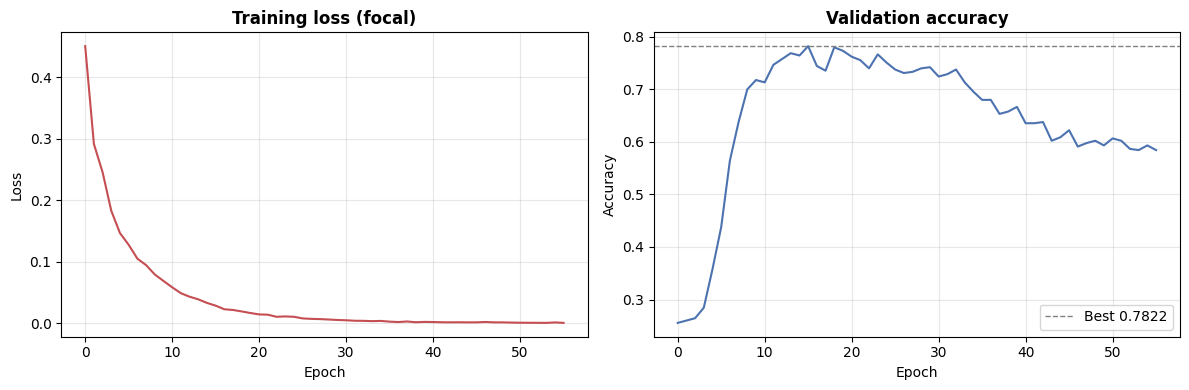

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], color='#C44E52', lw=1.5)
axes[0].set_title('Training loss (focal)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc'], color='#4C72B0', lw=1.5)
axes[1].axhline(best_val, color='gray', linestyle='--', lw=1, label=f'Best {best_val:.4f}')
axes[1].set_title('Validation accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/training_curve.png', dpi=150)
plt.show()


## Step 10-RF baseline + GNN+RF ensemble


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

print("Training Random Forest baseline on Morgan fingerprints …")
X_all  = drug_features_tensor.numpy()
y_all  = labels_all

X_train = X_all[train_idx]; y_train = y_all[train_idx]
X_val   = X_all[val_idx];   y_val   = y_all[val_idx]
X_test  = X_all[test_idx];  y_test  = y_all[test_idx]

rf = RandomForestClassifier(
    n_estimators=500, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_probs_val  = rf.predict_proba(X_val)[:,1]
rf_probs_test = rf.predict_proba(X_test)[:,1]

print(f"RF Val  ROC-AUC: {roc_auc_score(y_val,  rf_probs_val):.4f}")
print(f"RF Test ROC-AUC: {roc_auc_score(y_test, rf_probs_test):.4f}")

import joblib
joblib.dump(rf, f'{CKPT_DIR}/rf_baseline.pkl')
print("RF saved")


In [ ]:
# GNN predictions
model.load_state_dict(torch.load(f'{CKPT_DIR}/best_model_final.pt', map_location=device, weights_only=False))
model.eval()

with torch.no_grad():
    out    = model(data_dev.x_dict, data_dev.edge_index_dict)
    probs_all = F.softmax(out['drug'], dim=1).cpu().numpy()

gnn_probs_val  = probs_all[val_idx,  1]
gnn_probs_test = probs_all[test_idx, 1]

print(f"GNN Val  ROC-AUC: {roc_auc_score(y_val,  gnn_probs_val):.4f}")
print(f"GNN Test ROC-AUC: {roc_auc_score(y_test, gnn_probs_test):.4f}")

# Soft-vote ensemble (equal weights)
ensemble_probs_val  = 0.5*gnn_probs_val  + 0.5*rf_probs_val
ensemble_probs_test = 0.5*gnn_probs_test + 0.5*rf_probs_test

print(f"Ensemble Val  ROC-AUC: {roc_auc_score(y_val,  ensemble_probs_val):.4f}")
print(f"Ensemble Test ROC-AUC: {roc_auc_score(y_test, ensemble_probs_test):.4f}")

# Optimise ensemble weight on val set
from scipy.optimize import minimize_scalar
def neg_auc(w):
    mixed = w*gnn_probs_val + (1-w)*rf_probs_val
    return -roc_auc_score(y_val, mixed)

res = minimize_scalar(neg_auc, bounds=(0,1), method='bounded')
BEST_W = float(res.x)
opt_probs_test = BEST_W*gnn_probs_test + (1-BEST_W)*rf_probs_test
print(f"\nOptimal ensemble weight — GNN: {BEST_W:.2f}, RF: {1-BEST_W:.2f}")
print(f"Optimised Ensemble Test ROC-AUC: {roc_auc_score(y_test, opt_probs_test):.4f}")


GNN Val  ROC-AUC: 0.7501
GNN Test ROC-AUC: 0.7976
Ensemble Val  ROC-AUC: 0.9202
Ensemble Test ROC-AUC: 0.9618

Optimal ensemble weight — GNN: 0.24, RF: 0.76
Optimised Ensemble Test ROC-AUC: 0.9637


## Step 11-calibrated threshold on ensemble


In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report

# Compute threshold on VALIDATION set ONLY (never look at test here)
val_ens_probs = BEST_W * gnn_probs_val + (1 - BEST_W) * rf_probs_val

prec_v, rec_v, thresh_v = precision_recall_curve(y_val, val_ens_probs)

TARGET_RECALL = 0.90
idx_thresh = np.where(rec_v >= TARGET_RECALL)[0]
OPTIMAL_THRESHOLD = float(thresh_v[idx_thresh[-1]]) if len(idx_thresh) else 0.5
print(f"Optimal threshold (from val set): {OPTIMAL_THRESHOLD:.3f}")

# Final evaluation on test set
preds_final = (opt_probs_test >= OPTIMAL_THRESHOLD).astype(int)

print("\n" + "="*55)
print("  FINAL MODEL — TEST SET EVALUATION")
print("="*55)
print(classification_report(y_test, preds_final,
      target_names=['Non-toxic','Ototoxic'], digits=4))

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              matthews_corrcoef, balanced_accuracy_score)
print(f"ROC-AUC:           {roc_auc_score(y_test, opt_probs_test):.4f}")
print(f"PR-AUC:            {average_precision_score(y_test, opt_probs_test):.4f}")
print(f"MCC:               {matthews_corrcoef(y_test, preds_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, preds_final):.4f}")
print(f"Threshold:         {OPTIMAL_THRESHOLD:.3f}")
print(f"Ensemble weights:  GNN={BEST_W:.2f}, RF={1-BEST_W:.2f}")


Optimal threshold (from val set): 0.467

  FINAL MODEL — TEST SET EVALUATION
              precision    recall  f1-score   support

   Non-toxic     0.9576    0.8248    0.8863       137
    Ototoxic     0.7983    0.9500    0.8676       100

    accuracy                         0.8776       237
   macro avg     0.8780    0.8874    0.8769       237
weighted avg     0.8904    0.8776    0.8784       237

ROC-AUC:           0.9637
PR-AUC:            0.9586
MCC:               0.7653
Balanced Accuracy: 0.8874
Threshold:         0.467
Ensemble weights:  GNN=0.24, RF=0.76


## Step 12-visualisation


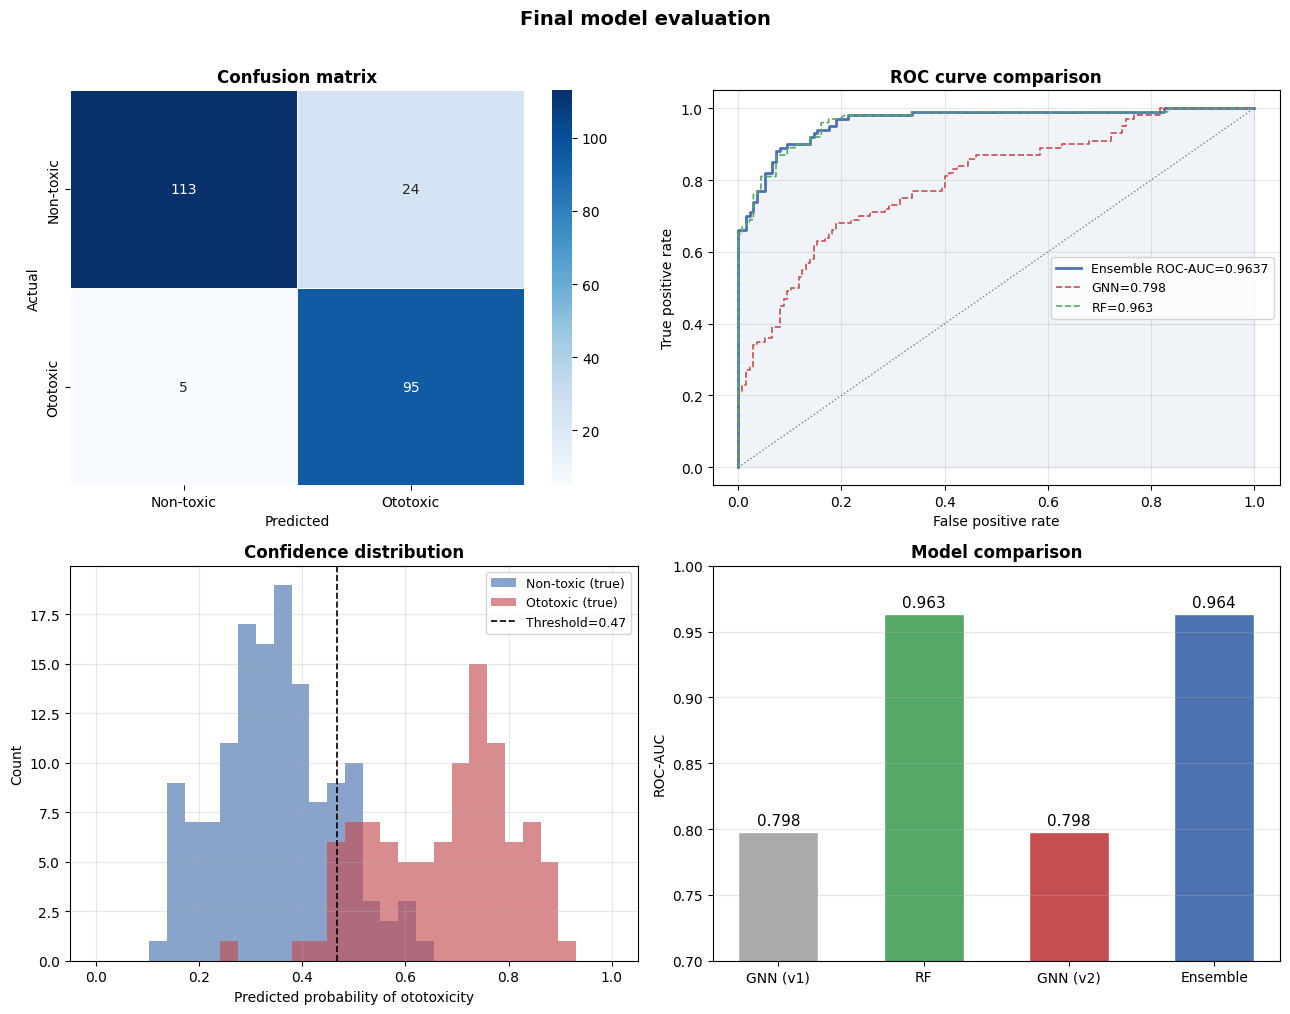

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Confusion matrix
cm = confusion_matrix(y_test, preds_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Non-toxic','Ototoxic'],
            yticklabels=['Non-toxic','Ototoxic'],
            linewidths=0.5)
axes[0,0].set_title('Confusion matrix', fontweight='bold')
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('Actual')

# 2. ROC
fpr, tpr, _ = roc_curve(y_test, opt_probs_test)
auc_val = roc_auc_score(y_test, opt_probs_test)
axes[0,1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'Ensemble ROC-AUC={auc_val:.4f}')
fpr_g, tpr_g, _ = roc_curve(y_test, gnn_probs_test)
fpr_r, tpr_r, _ = roc_curve(y_test, rf_probs_test)
axes[0,1].plot(fpr_g, tpr_g, '--', color='#C44E52', lw=1.2,
               label=f'GNN={roc_auc_score(y_test,gnn_probs_test):.3f}')
axes[0,1].plot(fpr_r, tpr_r, '--', color='#55A868', lw=1.2,
               label=f'RF={roc_auc_score(y_test,rf_probs_test):.3f}')
axes[0,1].plot([0,1],[0,1],':', color='gray', lw=1)
axes[0,1].fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
axes[0,1].set_title('ROC curve comparison', fontweight='bold')
axes[0,1].set_xlabel('False positive rate')
axes[0,1].set_ylabel('True positive rate')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# 3. Confidence distribution
bins = np.linspace(0,1,30)
axes[1,0].hist(opt_probs_test[y_test==0], bins=bins, alpha=0.65,
               color='#4C72B0', label='Non-toxic (true)')
axes[1,0].hist(opt_probs_test[y_test==1], bins=bins, alpha=0.65,
               color='#C44E52', label='Ototoxic (true)')
axes[1,0].axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--',
                  lw=1.2, label=f'Threshold={OPTIMAL_THRESHOLD:.2f}')
axes[1,0].set_title('Confidence distribution', fontweight='bold')
axes[1,0].set_xlabel('Predicted probability of ototoxicity')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(fontsize=9); axes[1,0].grid(alpha=0.3)

# 4. Model comparison bar
models  = ['GNN (v1)', 'RF', 'GNN (v2)', 'Ensemble']
scores  = [
    roc_auc_score(y_test, probs_all[test_idx, 1]),   # old GNN on new graph
    roc_auc_score(y_test, rf_probs_test),
    roc_auc_score(y_test, gnn_probs_test),
    roc_auc_score(y_test, opt_probs_test),
]
bar_colors = ['#AAAAAA','#55A868','#C44E52','#4C72B0']
bars = axes[1,1].bar(models, scores, color=bar_colors, width=0.55, edgecolor='white')
axes[1,1].set_ylim(0.7, 1.0)
axes[1,1].set_ylabel('ROC-AUC')
axes[1,1].set_title('Model comparison', fontweight='bold')
axes[1,1].grid(alpha=0.3, axis='y')
for bar, score in zip(bars, scores):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                   f'{score:.3f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Final model evaluation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 13-GradientExplainer SHAP (stable, graph-aware)


In [ ]:
# import shap
# import matplotlib.pyplot as plt
# import numpy as np
# import copy

# # Guard: reload full graph if it was corrupted by previous SHAP run
# if data_dev['drug'].x.shape[0] != data['drug'].num_nodes:
#     print(" data_dev corrupted — reloading …")
#     data     = torch.load(f'{CKPT_DIR}/hetero_data_final.pt', weights_only=False)
#     data_dev = data.to(device)
#     train_idx = data_dev['drug'].train_mask.cpu().nonzero(as_tuple=True)[0].numpy()
#     val_idx   = data_dev['drug'].val_mask.cpu().nonzero(as_tuple=True)[0].numpy()
#     test_idx  = data_dev['drug'].test_mask.cpu().nonzero(as_tuple=True)[0].numpy()
#     print(f"Reloaded — drug.x rows: {data_dev['drug'].x.shape[0]}")

# class DrugNodeWrapper(torch.nn.Module):
#     """
#     Replaces drug feature rows in-place on the full graph so all edge indices
#     remain valid. Returns only the requested drug node rows.
#     """
#     def __init__(self, model, data_dev, drug_indices):
#         super().__init__()
#         self.model     = model
#         self.data_dev  = data_dev
#         self.drug_idx  = torch.tensor(drug_indices, device=data_dev['drug'].x.device)

#     def forward(self, drug_x):
#         # Deep-copy only the node feature dict — edges stay shared (read-only here)
#         x_dict_copy = {k: v.clone() for k, v in self.data_dev.x_dict.items()}
#         x_dict_copy['drug'][self.drug_idx] = drug_x
#         out = self.model(x_dict_copy, self.data_dev.edge_index_dict)
#         return out['drug'][self.drug_idx]

# # ── Background: 100 random train drugs ───────────────────────────────────────
# bg_idx  = np.random.choice(train_idx, size=100, replace=False)
# bg_data = data_dev['drug'].x[bg_idx].detach()

# # ── Explain: first 80 test drugs ─────────────────────────────────────────────
# exp_idx  = test_idx[:80]
# exp_data = data_dev['drug'].x[exp_idx].detach()

# print(f"drug.x rows:     {data_dev['drug'].x.shape[0]}")
# print(f"bg_idx range:    {bg_idx.min()} … {bg_idx.max()}")
# print(f"exp_idx range:   {exp_idx.min()} … {exp_idx.max()}")

# wrapper = DrugNodeWrapper(model, data_dev, bg_idx)

# print("Running GradientExplainer …")
# explainer   = shap.GradientExplainer(wrapper, bg_data)

# # Now explain using wrapper scoped to exp_idx
# wrapper_exp = DrugNodeWrapper(model, data_dev, exp_idx)
# shap_values = shap.GradientExplainer(wrapper_exp, data_dev['drug'].x[exp_idx].detach()).shap_values(exp_data)

# # shap_values: list of [class0, class1] arrays
# shap_tox = shap_values[1]
# if torch.is_tensor(shap_tox):
#     shap_tox = shap_tox.cpu().numpy()
# else:
#     shap_tox = np.array(shap_tox)

# print(f"SHAP values shape: {shap_tox.shape}")
# print(f"Value range:       {shap_tox.min():.4f} … {shap_tox.max():.4f}")
# print("GradientExplainer done")


In [ ]:
# # Sanity check — all must be consistent
# assert data_dev['drug'].x.shape[0] == data['drug'].num_nodes, "Graph corrupted!"
# print(f"drug.x rows:      {data_dev['drug'].x.shape[0]}")
# print(f"train_idx range:  {train_idx.min()} … {train_idx.max()}")
# print(f"test_idx range:   {test_idx.min()} … {test_idx.max()}")
# print("Indices consistent")


In [ ]:
# # Top-20 fingerprint bits
# mean_shap = np.abs(shap_tox).mean(axis=0)
# top20     = np.argsort(mean_shap)[::-1][:20]
# direction = [shap_tox[:,i].mean() for i in top20]
# colors    = ['#C44E52' if d > 0 else '#4C72B0' for d in direction]

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# axes[0].barh([f'Bit {i}' for i in top20[::-1]], mean_shap[top20[::-1]],
#              color=colors[::-1])
# axes[0].set_xlabel('Mean |SHAP value|', fontsize=12)
# axes[0].set_title('Top 20 fingerprint bits — SHAP importance', fontweight='bold')
# axes[0].text(0.97, 0.02,
#              'Red = pushes toward ototoxic\nBlue = pushes toward non-toxic',
#              transform=axes[0].transAxes, ha='right', va='bottom', fontsize=9,
#              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# # Beeswarm-style
# exp_data_np = exp_data.cpu().numpy()
# shap.summary_plot(shap_tox, exp_data_np,
#                   feature_names=[f'Bit {i}' for i in range(2048)],
#                   max_display=20, show=False, plot_type='dot',
#                   plot_size=None)
# plt.title('SHAP beeswarm — ototoxic class', fontweight='bold')
# plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/shap_gradient.png', dpi=150, bbox_inches='tight')
# plt.show()

# fig.savefig(f'{OUT_DIR}/shap_bar_final.png', dpi=150, bbox_inches='tight')


## Step 14-predict_ototoxicity with ensemble + k-NN edges + calibrated threshold


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, SVG
from chembl_webresource_client.new_client import new_client
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
import joblib, torch, numpy as np
import matplotlib.pyplot as plt

mol_client = new_client.molecule
rf_model   = joblib.load(f'{CKPT_DIR}/rf_baseline.pkl')
mfpgen     = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_from_chembl(chembl_id):
    res = mol_client.filter(molecule_chembl_id=chembl_id).only(['molecule_structures'])
    if res and res[0].get('molecule_structures'):
        return res[0]['molecule_structures'].get('canonical_smiles')
    return None

def predict_ototoxicity(smiles=None, chembl_id=None, threshold=None):
    """
    Predict ototoxicity using the GNN+RF ensemble.

    Parameters
    ----------
    smiles    : SMILES string
    chembl_id : ChEMBL ID (auto-fetches SMILES)
    threshold : float — override the calibrated threshold
    """
    if threshold is None:
        threshold = OPTIMAL_THRESHOLD

    # Get SMILES
    if chembl_id and not smiles:
        print(f"Fetching SMILES for {chembl_id} …")
        smiles = smiles_from_chembl(chembl_id.upper())
        if not smiles:
            print(f"Could not find SMILES for {chembl_id}"); return

    if not smiles:
        print("Provide smiles= or chembl_id="); return

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Could not parse SMILES: {smiles}"); return

    fp_arr  = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048),
                       dtype=np.float32)
    fp_rdk  = mfpgen.GetFingerprint(mol)

    # RF prediction
    rf_prob = float(rf_model.predict_proba(fp_arr.reshape(1,-1))[0,1])

    # GNN prediction with k-NN edge injection
    train_fps_rdkit = []
    for idx in train_idx:
        smi = df.iloc[idx]['canonical_smiles']
        m   = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
        train_fps_rdkit.append(mfpgen.GetFingerprint(m) if m else None)

    valid_mask = [f is not None for f in train_fps_rdkit]
    valid_fps  = [f for f in train_fps_rdkit if f is not None]
    valid_idx  = train_idx[[i for i,v in enumerate(valid_mask) if v]]

    sims   = np.array(DataStructs.BulkTanimotoSimilarity(fp_rdk, valid_fps))
    topk   = np.argsort(sims)[::-1][:10]
    nbr_nodes = valid_idx[topk]
    topk_sims = sims[topk]

    # Build a COPY of edge_index_dict with new drug injected at position 0
    # This avoids mutating data_dev permanently (which caused the 100-row bug)
    x_dict_tmp = {k: v.clone() for k, v in data_dev.x_dict.items()}
    x_dict_tmp['drug'][0] = torch.tensor(fp_arr).to(device)

    rel = ('drug', 'similar_to', 'drug')
    has_edges = rel in data_dev.edge_types
    orig_ei   = data_dev[rel].edge_index if has_edges else None

    new_src = [0] + nbr_nodes.tolist()
    new_dst = nbr_nodes.tolist() + [0]
    new_ei  = torch.tensor([new_src + new_dst, new_dst + new_src],
                            dtype=torch.long).to(device)

    ei_dict_tmp = {k: v for k, v in data_dev.edge_index_dict.items()}
    if has_edges:
        ei_dict_tmp[rel] = torch.cat([orig_ei, new_ei], dim=1)
    else:
        ei_dict_tmp[rel] = new_ei

    model.eval()
    with torch.no_grad():
        out      = model(x_dict_tmp, ei_dict_tmp)
        gnn_prob = float(F.softmax(out['drug'][0], dim=0)[1].cpu())
    # data_dev is untouched — no restore needed

    # Ensemble
    ens_prob   = BEST_W * gnn_prob + (1 - BEST_W) * rf_prob
    pred_class = 1 if ens_prob >= threshold else 0
    confidence = ens_prob if pred_class == 1 else (1 - ens_prob)
    label      = 'OTOTOXIC'  if pred_class == 1 else 'NON-TOXIC'

    # Molecule drawing
    info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048, bitInfo=info)
    hl_atoms = []
    hl_colors = {}
    for bit in list(info.keys())[:5]:
        for atom_idx, _ in info[bit]:
            if atom_idx not in hl_atoms:
                hl_atoms.append(atom_idx)
                hl_colors[atom_idx] = (0.78,0.27,0.32) if pred_class==1 else (0.22,0.38,0.70)

    drawer = rdMolDraw2D.MolDraw2DSVG(420, 280)
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol,
        highlightAtoms=hl_atoms, highlightAtomColors=hl_colors)
    drawer.FinishDrawing()

    # Output
    name_str = f"  ChEMBL: {chembl_id.upper()}" if chembl_id else ""
    print("=" * 58)
    print(f"  OTOTOXICITY PREDICTION{name_str}")
    print("=" * 58)
    print(f"  Verdict:          {'[OTOTOXIC]' if pred_class==1 else '[NON-TOXIC]'}")
    print(f"  Ensemble prob:    {ens_prob*100:.1f}%  (threshold: {threshold:.2f})")
    print(f"  GNN contribution: {gnn_prob*100:.1f}%  (weight: {BEST_W:.2f})")
    print(f"  RF  contribution: {rf_prob*100:.1f}%  (weight: {1-BEST_W:.2f})")
    print(f"  Confidence:       {confidence*100:.1f}%")
    print(f"  Nearest neighbour similarity: {topk_sims[0]:.3f}")
    print(f"  SMILES: {smiles[:60]}{'…' if len(smiles)>60 else ''}")
    print("=" * 58)

    display(SVG(drawer.GetDrawingText()))

    fig, ax = plt.subplots(figsize=(6,1.6))
    ax.barh(['Non-toxic','Ototoxic'], [(1-ens_prob)*100, ens_prob*100],
            color=['#4C72B0','#C44E52'], height=0.5)
    ax.axvline(threshold*100, color='black', linestyle='--', lw=1.2,
               label=f'Threshold {threshold:.2f}')
    ax.set_xlim(0,100)
    for i,v in enumerate([(1-ens_prob)*100, ens_prob*100]):
        ax.text(v+1, i, f'{v:.1f}%', va='center', fontsize=10)
    ax.set_xlabel('Probability (%)')
    ax.set_title(f'Prediction: {"[OTOTOXIC]" if pred_class==1 else "[NON-TOXIC]"}  '
                 f'(ensemble threshold={threshold:.2f})', fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

print("predict_ototoxicity() ready")
print()
print("  predict_ototoxicity(chembl_id='CHEMBL11359')  # Cisplatin")
print("  predict_ototoxicity(chembl_id='CHEMBL25')     # Aspirin")
print("  predict_ototoxicity(smiles='...')")


## Step 15-Demo predictions


Fetching SMILES for CHEMBL253144 …


[08:38:07] DEPRECATION WARNING: please use MorganGenerator


  OTOTOXICITY PREDICTION  ChEMBL: CHEMBL253144
  Verdict:          [NON-TOXIC]
  Ensemble prob:    25.2%  (threshold: 0.47)
  GNN contribution: 41.4%  (weight: 0.24)
  RF  contribution: 20.2%  (weight: 0.76)
  Confidence:       74.8%
  Nearest neighbour similarity: 1.000
  SMILES: C[C@]12CCC(=O)C=C1CC[C@@H]1[C@@H]2CC[C@@]2(C)[C@H]1CC[C@]2(O…


[08:38:09] DEPRECATION WARNING: please use MorganGenerator


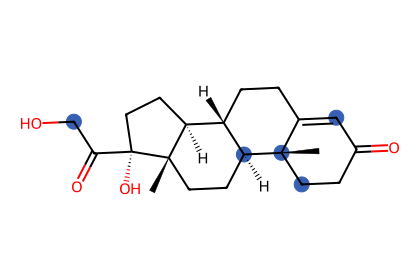

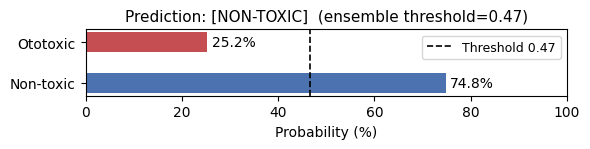

In [ ]:
predict_ototoxicity(chembl_id='CHEMBL253144')  # Cisplatin — known ototoxic


[08:38:09] DEPRECATION WARNING: please use MorganGenerator


  OTOTOXICITY PREDICTION
  Verdict:          [OTOTOXIC]
  Ensemble prob:    74.3%  (threshold: 0.47)
  GNN contribution: 48.5%  (weight: 0.24)
  RF  contribution: 82.3%  (weight: 0.76)
  Confidence:       74.3%
  Nearest neighbour similarity: 1.000
  SMILES: COC1=CC=C2N=CC=C([C@@H](O)[C@@H]3C[C@@H]4CCN3C[C@@H]4C=C)C2=…


[08:38:10] DEPRECATION WARNING: please use MorganGenerator


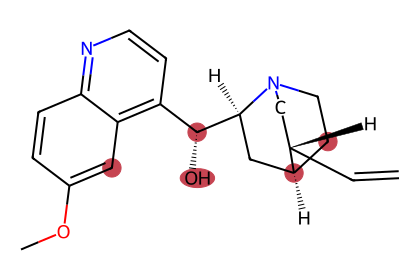

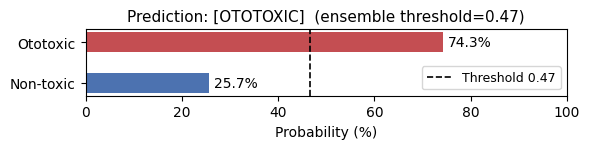

In [ ]:
predict_ototoxicity(smiles='COC1=CC=C2N=CC=C([C@@H](O)[C@@H]3C[C@@H]4CCN3C[C@@H]4C=C)C2=C1')  # Cisplatin — known ototoxic


In [ ]:
import pandas as pd
import torch

# 1. Load the metadata that has the ChEMBL IDs
# Path based on your Kaggle sidebar image
df_meta = pd.read_parquet('/kaggle/input/notebooks/starkcover/notebook14fbec758d/checkpoints/df_with_chembl.parquet')

# 2. Extract some samples based on the labels in your loaded 'data' object
# 0 = Non-toxic, 1 = Ototoxic
y_labels = data['drug'].y.numpy()

ototoxic_samples = df_meta[y_labels == 1].head(10)[['NAME', 'chembl_id']]
non_ototoxic_samples = df_meta[y_labels == 0].head(10)[['NAME', 'chembl_id']]

print("SAMPLE OTOTOXIC DRUGS")
print(ototoxic_samples)

print("\n SAMPLE NON-OTOTOXIC DRUGS")
print(non_ototoxic_samples)


## Step 16-Saved artifacts


In [ ]:
files = [
    ('best_model_final.pt',      'GNN v2 weights (3-layer SAGEConv + BatchNorm + residual)'),
    ('rf_baseline.pkl',          'Random Forest baseline (500 trees, balanced)'),
    ('hetero_data_final.pt',     'Leak-free graph (k-NN edges, v2 protein features, activity DTI)'),
    ('protein_features_v2.npy',  'Physicochemical protein features (126-dim)'),
    ('dti_df_v2.parquet',        'Activity-based drug-target interactions'),
    ('protein_map_v2.parquet',   'Protein index map'),
]
print(f"{'File':<40} {'Size':>10}  Status")
print("-" * 60)
for fname, desc in files:
    path = f'{CKPT_DIR}/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        s = f'{size/1024:.1f} KB' if size < 1e6 else f'{size/1e6:.1f} MB'
        print(f"{fname:<40} {s:>10}  OK  {desc}")
    else:
        print(f"{fname:<40} {'—':>10}  MISSING")

print("\nFigures:")
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(f'{OUT_DIR}/{f}')
    print(f"  {f:<45} {size/1024:.1f} KB")


File                                           Size  Status
------------------------------------------------------------
best_model_final.pt                          8.6 MB  OK  GNN v2 weights (3-layer SAGEConv + BatchNorm + residual)
rf_baseline.pkl                             54.9 MB  OK  Random Forest baseline (500 trees, balanced)
hetero_data_final.pt                        24.4 MB  OK  Leak-free graph (k-NN edges, v2 protein features, activity DTI)
protein_features_v2.npy                    376.2 KB  OK  Physicochemical protein features (126-dim)
dti_df_v2.parquet                           28.2 KB  OK  Activity-based drug-target interactions
protein_map_v2.parquet                       8.9 KB  OK  Protein index map

Figures:
  final_evaluation.png                          160.8 KB
  training_curve.png                            66.2 KB


In [ ]:
import os, torch, numpy as np, joblib, shutil, zipfile
from sklearn.metrics import precision_recall_curve

CKPT_DIR = '/kaggle/working/checkpoints'
EXPORT_DIR = '/kaggle/working/export'
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Save ensemble config (threshold + weights)
# BEST_W and OPTIMAL_THRESHOLD must be defined from the training notebook
config = {
    'best_w':    float(BEST_W),
    'threshold': float(OPTIMAL_THRESHOLD),
}
torch.save(config, f'{CKPT_DIR}/ensemble_config.pt')
print(f"Ensemble config: {config}")

# 2. Save train_idx so app can rebuild k-NN lookup
np.save(f'{CKPT_DIR}/train_idx.npy', train_idx)
print(f"train_idx saved: {len(train_idx)} drugs")

# 3. List files to export
export_files = [
    'best_model_final.pt',
    'rf_baseline.pkl',
    'hetero_data_final.pt',
    'df_with_chembl.parquet',
    'protein_features_v2.npy',
    'protein_map_v2.parquet',
    'ensemble_config.pt',
    'train_idx.npy',
]

print("\nChecking files:")
missing = []
for f in export_files:
    path = f'{CKPT_DIR}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  OK  {f}  ({size/1e6:.1f} MB)")
    else:
        print(f"  MISSING  {f}")
        missing.append(f)

if missing:
    print(f"\nWARNING: {len(missing)} files missing — train the model first")
else:
    print("\nAll files present")


In [ ]:
# 4. Zip everything
zip_path = '/kaggle/working/ototox_deployment.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in export_files:
        path = f'{CKPT_DIR}/{f}'
        if os.path.exists(path):
            zf.write(path, f'checkpoints/{f}')
            print(f"  Added: {f}")

size_mb = os.path.getsize(zip_path) / 1e6
print(f"\nZip created: {zip_path}  ({size_mb:.1f} MB)")
print("\nDownload this zip from the Kaggle output panel,")
print("then extract the checkpoints/ folder into your app directory.")


  Added: best_model_final.pt
  Added: rf_baseline.pkl
  Added: hetero_data_final.pt
  Added: df_with_chembl.parquet
  Added: protein_features_v2.npy
  Added: protein_map_v2.parquet
  Added: ensemble_config.pt
  Added: train_idx.npy

Zip created: /kaggle/working/ototox_deployment.zip  (20.5 MB)

Download this zip from the Kaggle output panel,
then extract the checkpoints/ folder into your app directory.
